# Lecture 09 (B08): Constraints, residual kernels, and loss design

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §2.4 (Constraints); §2.9 (Residual kernels)  
**Notebook role:** core  
**Original live-course source:** `lectures/day2/code/05_StochasticBM_LossComparison.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Brock-Mirman with Stochastic TFP: Loss Functions and Convergence

*Companion notebook to **Day 2 — Deep Equilibrium Nets** (Chapter 2 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

This notebook studies how the *choice of training loss* in a DEQN affects
the **economic** convergence behaviour of the trained policy.

Two distinct objects are at play:

- **Training loss**: the scalar that the optimizer minimises (MSE, MAE,
  Huber, Quantile pinball, CVaR, LogCosh, ...).
- **Economic loss**: what we ultimately care about, the *relative Euler
  equation error along a simulated path*, which translates directly into a
  consumption-equivalent welfare loss.

These two are not the same. A loss that minimises the *mean* squared
residual may leave a heavy right tail of residuals concentrated in rarely
visited but economically consequential parts of the state space. We use the
stochastic Brock-Mirman model with **full depreciation**, where the optimal
savings rate is known in closed form,

$$
  s^\star \;=\; \alpha\beta,
$$

to measure the discrepancy exactly. The same network is trained six times,
once per loss kernel, with identical initialisation, optimizer, and training
states (common random numbers). Only the *reduction* applied to the Euler
residual differs.

**Companion to:** `02_Brock_Mirman_Uncertainty_DEQN.ipynb` (same model,
MSE only, partial depreciation). We switch to full depreciation here only
to expose a closed-form benchmark.

## 1. Model: Stochastic Brock-Mirman (1972)

- Production: $Y_t = e^{z_t} K_t^{\alpha}$
- AR(1) for log TFP: $z_{t+1} = \rho\, z_t + \sigma\, \varepsilon_{t+1}$, $\varepsilon \sim \mathcal{N}(0,1)$
- **Full depreciation**, so capital evolves as $K_{t+1} = s_t Y_t$
- Log utility, discount $\beta$
- Euler equation: $\;1 \;=\; \beta\,\mathbb{E}_t\!\left[\dfrac{C_t}{C_{t+1}}\,\alpha e^{z_{t+1}} K_{t+1}^{\alpha-1}\right]$
- **Closed-form optimal savings rate**: $s^\star = \alpha\beta$

The closed form is the reason for using $\delta=1$: it gives an exact reference against which any learned policy can be measured, including a single-number consumption-equivalent welfare loss.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time

plt.rcParams['font.size'] = 13
np.random.seed(0)
tf.random.set_seed(0)
tf.get_logger().setLevel('ERROR')   # silence harmless retracing warnings
print('TensorFlow', tf.__version__)

2026-04-27 11:20:53.910946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777281653.954935  588820 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777281653.967958  588820 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 11:20:54.005246: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0


In [2]:
# Calibration (matches Day 2 stochastic BM, except delta=1).
alpha     = 0.36
beta      = 0.99
rho_tfp   = 0.9
sigma_tfp = 0.04

# Closed-form optimal savings rate.
s_star = alpha * beta
print(f'Optimal savings rate s* = alpha * beta = {s_star:.4f}')

# Steady-state log capital (deterministic, full depreciation).
K_ss  = (alpha * beta) ** (1.0 / (1.0 - alpha))
lk_ss = float(np.log(K_ss))
print(f'Deterministic steady state: K* = {K_ss:.4f},   log K* = {lk_ss:.4f}')

# Gauss-Hermite quadrature for the conditional expectation.
n_int = 5
_xi, _w = np.polynomial.hermite.hermgauss(n_int)
GH_NODES   = tf.constant(_xi * np.sqrt(2.0), dtype=tf.float32)   # innovations eps ~ N(0,1)
GH_WEIGHTS = tf.constant(_w / np.sqrt(np.pi), dtype=tf.float32)  # sum to 1

Optimal savings rate s* = alpha * beta = 0.3564
Deterministic steady state: K* = 0.1995,   log K* = -1.6120


2026-04-27 11:20:58.960693: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Training-budget switch

All six losses share the same number of episodes; only the reduction kernel
varies. Choose `MODE` based on what you want to do:

| MODE | episodes / loss | total wall-clock (CPU) |
|------|----------------:|-----------------------:|
| `smoke`     |  300 | ~30 s |
| `classroom` | 1500 | ~3 min |
| `production`| 5000 | ~10 min |

In [3]:
MODE = 'classroom'   # 'smoke' | 'classroom' | 'production'

if MODE == 'smoke':
    N_EPISODES, BATCH_SIZE, EVAL_EVERY = 300, 64, 25
elif MODE == 'classroom':
    N_EPISODES, BATCH_SIZE, EVAL_EVERY = 1500, 64, 50
elif MODE == 'production':
    N_EPISODES, BATCH_SIZE, EVAL_EVERY = 5000, 128, 100
else:
    raise ValueError(MODE)

print(f'MODE={MODE!r}: N_EPISODES={N_EPISODES}, BATCH_SIZE={BATCH_SIZE}, EVAL_EVERY={EVAL_EVERY}')

MODE='production': N_EPISODES=5000, BATCH_SIZE=128, EVAL_EVERY=100


## 3. Network

Identical 2x32 swish architecture across all six runs. Weights are saved
once and reloaded for each loss kind so all runs start from the same point
(this is what makes the comparison fair).

In [4]:
def make_network(seed=42):
    return keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(32, activation='swish',
            kernel_initializer=keras.initializers.GlorotUniform(seed=seed)),
        keras.layers.Dense(32, activation='swish',
            kernel_initializer=keras.initializers.GlorotUniform(seed=seed+1)),
        keras.layers.Dense(1,  activation='sigmoid',
            kernel_initializer=keras.initializers.GlorotUniform(seed=seed+2)),
    ])

_init_nn = make_network(seed=42)
INIT_WEIGHTS = _init_nn.get_weights()
_init_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Euler residual and ground truth

We work with the **relative** residual

$$ r(k_t,z_t) \;=\; \beta\,\mathbb{E}_t\!\Big[\tfrac{C_t}{C_{t+1}}\, \alpha e^{z_{t+1}} K_{t+1}^{\alpha-1}\Big] - 1, $$

evaluated by Gauss-Hermite quadrature. Every loss kernel below is a
different *reduction* of $r$ to a scalar; the residual itself is identical
across runs.

In [5]:
@tf.function
def euler_residual(state, nn):
    '''Return relative Euler residual r at each state. state shape (B, 2).
       Columns: (z_t, log K_t).  s_t comes from the network, sigmoid -> (0,1).'''
    z_t  = state[:, 0:1]
    lk_t = state[:, 1:2]
    Z_t  = tf.exp(z_t)
    K_t  = tf.exp(lk_t)
    Y_t  = Z_t * K_t**alpha
    s_t  = nn(state)
    K_tp1 = s_t * Y_t                       # delta = 1
    C_t   = (1.0 - s_t) * Y_t
    lk_tp1 = tf.math.log(K_tp1)

    expectation = tf.zeros_like(z_t)
    for q in range(n_int):
        eps_q  = GH_NODES[q]                # already includes sqrt(2)
        z_tp1  = rho_tfp * z_t + sigma_tfp * eps_q
        Z_tp1  = tf.exp(z_tp1)
        state_tp1 = tf.concat([z_tp1, lk_tp1], axis=1)
        s_tp1  = nn(state_tp1)
        Y_tp1  = Z_tp1 * K_tp1**alpha
        C_tp1  = (1.0 - s_tp1) * Y_tp1
        r_tp1  = alpha * Z_tp1 * K_tp1**(alpha - 1.0)
        integrand = (C_t / C_tp1) * r_tp1
        expectation = expectation + GH_WEIGHTS[q] * integrand
    return beta * expectation - 1.0

## 5. The six loss kernels

All operate on the same vector $r \in \mathbb{R}^B$ produced by the cell
above. Only the reduction differs:

| Kernel | Formula | Emphasis |
|---|---|---|
| **MSE**      | $\frac1B\sum r^2$ | mean of squared residuals (canonical DEQN choice) |
| **MAE**      | $\frac1B\sum \|r\|$ | median, robust to outliers; **gradient magnitude is constant**, so progress at small residuals stalls |
| **Huber**    | quadratic for $\|r\| \le \delta$, linear above | smooth hybrid of MSE / MAE, but the quadratic-to-linear switch at $\|r\|{=}\delta$ is a kink in the gradient |
| **Quantile** | pinball at $\tau{=}0.9$: $\max(\tau r,(\tau{-}1)r)$ | trains the upper $\tau$-quantile of $r$ specifically |
| **CVaR**     | mean of top $(1{-}\alpha){=}10\%$ of $\|r\|$ | tail mean - explicitly trains the bad regions |
| **LogCosh**  | $\frac1B\sum \log\cosh(r)$ | smooth ($C^\infty$) hybrid: $\frac{1}{2}r^2$ near zero, $\|r\|-\log 2$ in the tails - quadratic curvature where it helps fine convergence, linear asymptote where it tames outliers, *no kink anywhere* |

In [6]:
def make_loss(kind, **kw):
    '''Return a function residuals -> scalar loss. All operate on the same r.'''
    if kind == 'MSE':
        return lambda r: tf.reduce_mean(r**2)
    if kind == 'MAE':
        return lambda r: tf.reduce_mean(tf.abs(r))
    if kind == 'Huber':
        delta = tf.constant(kw.get('delta', 1e-2), dtype=tf.float32)
        def huber(r):
            ar = tf.abs(r)
            quad = 0.5 * r**2
            lin  = delta * (ar - 0.5 * delta)
            return tf.reduce_mean(tf.where(ar <= delta, quad, lin))
        return huber
    if kind == 'Quantile':
        tau = tf.constant(kw.get('tau', 0.9), dtype=tf.float32)
        def pinball(r):
            return tf.reduce_mean(tf.maximum(tau * r, (tau - 1.0) * r))
        return pinball
    if kind == 'CVaR':
        alpha_cvar = float(kw.get('alpha', 0.9))
        def cvar(r):
            abs_r = tf.abs(tf.reshape(r, [-1]))
            n = tf.shape(abs_r)[0]
            k = tf.maximum(tf.cast(tf.cast(n, tf.float32) * (1.0 - alpha_cvar), tf.int32), 1)
            top_k_vals, _ = tf.math.top_k(abs_r, k=k)
            return tf.reduce_mean(top_k_vals)
        return cvar
    if kind == 'LogCosh':
        return lambda r: tf.reduce_mean(tf.math.log(tf.math.cosh(r)))
    raise ValueError(kind)

LOSS_KINDS = ['MSE', 'MAE', 'Huber', 'Quantile', 'CVaR', 'LogCosh']

## 6. Common random numbers

We pre-generate every training batch once: each loss run sees *exactly the
same* sequence of training states. The only difference between runs is the
reduction applied to the residual. This is what makes the comparison fair.
Evaluation is done on a fixed $(z, \log K)$ grid spanning the ergodic support.

In [7]:
SEED = 42
rng  = np.random.default_rng(SEED)

# Pre-generate every training batch (same for all losses).
TOTAL = N_EPISODES * BATCH_SIZE
z_sd_ergodic = sigma_tfp / np.sqrt(1.0 - rho_tfp**2)
z_train  = rng.normal(loc=0.0, scale=z_sd_ergodic, size=TOTAL).astype(np.float32)
lk_train = rng.uniform(low=lk_ss - 0.5, high=lk_ss + 0.5, size=TOTAL).astype(np.float32)
TRAIN_STATES = tf.constant(np.stack([z_train, lk_train], axis=1))

# Evaluation grid: 21 x 21 in (z, log K) covering ~3 sigma of the ergodic dist.
z_eval_grid  = np.linspace(-3.0 * z_sd_ergodic, 3.0 * z_sd_ergodic, 21).astype(np.float32)
lk_eval_grid = np.linspace(lk_ss - 0.4, lk_ss + 0.4, 21).astype(np.float32)
ZZ, LK = np.meshgrid(z_eval_grid, lk_eval_grid, indexing='ij')
EVAL_STATES = tf.constant(np.stack([ZZ.ravel(), LK.ravel()], axis=1))

# Welfare-comparison shocks: one fixed sequence used for every kind.
T_PATH = 2000
PATH_INNOVATIONS = tf.constant(rng.normal(size=T_PATH).astype(np.float32))

print(f'Training points pre-generated: {TOTAL}')
print(f'Eval grid: {EVAL_STATES.shape[0]} states')
print(f'Welfare path length: {T_PATH}')

Training points pre-generated: 640000
Eval grid: 441 states
Welfare path length: 2000


## 7. Training rig

One JIT-compiled `train_step` per loss kind (the loss function is captured
in the closure, so each kind compiles its own graph). Per-episode logging
evaluates the *economic* metric (relative Euler error on the eval grid)
every `EVAL_EVERY` steps.

In [8]:
def fresh_nn():
    nn = make_network(seed=42)
    nn.set_weights(INIT_WEIGHTS)
    return nn

def make_train_step(loss_fn):
    @tf.function
    def step(batch_states, nn, optimizer):
        with tf.GradientTape() as tape:
            r = euler_residual(batch_states, nn)
            loss = loss_fn(r)
        grads = tape.gradient(loss, nn.trainable_variables)
        optimizer.apply_gradients(zip(grads, nn.trainable_variables))
        return loss
    return step

def run_one_loss(kind, **kw):
    nn        = fresh_nn()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn   = make_loss(kind, **kw)
    step      = make_train_step(loss_fn)

    log_train_loss, log_mean, log_p90, log_p99 = [], [], [], []
    eval_eps = []

    t0 = time.time()
    for e in range(N_EPISODES):
        batch = TRAIN_STATES[e * BATCH_SIZE : (e + 1) * BATCH_SIZE]
        loss  = float(step(batch, nn, optimizer))
        if (e % EVAL_EVERY) == 0 or e == N_EPISODES - 1:
            r_eval = euler_residual(EVAL_STATES, nn).numpy().ravel()
            ar     = np.abs(r_eval)
            log_train_loss.append(loss)
            log_mean.append(ar.mean())
            log_p90.append(np.quantile(ar, 0.90))
            log_p99.append(np.quantile(ar, 0.99))
            eval_eps.append(e)
    elapsed = time.time() - t0
    return dict(kind=kind, nn=nn,
                eval_eps=np.array(eval_eps),
                train_loss=np.array(log_train_loss),
                eval_mean=np.array(log_mean),
                eval_p90=np.array(log_p90),
                eval_p99=np.array(log_p99),
                elapsed=elapsed)

In [9]:
results = {}
for kind in LOSS_KINDS:
    print(f'Training with {kind:<9s} loss ...', end=' ', flush=True)
    results[kind] = run_one_loss(kind)
    r = results[kind]
    print(f'done in {r["elapsed"]:5.1f}s | final mean |r|={r["eval_mean"][-1]:.2e}, p99|r|={r["eval_p99"][-1]:.2e}')

Training with MSE       loss ... 

done in  18.5s | final mean |r|=1.37e-04, p99|r|=4.03e-04
Training with MAE       loss ... 

done in  21.4s | final mean |r|=2.51e-03, p99|r|=2.91e-03
Training with Huber     loss ... 

done in  18.7s | final mean |r|=3.95e-04, p99|r|=6.24e-04
Training with Quantile  loss ... 

done in  18.0s | final mean |r|=1.16e-03, p99|r|=2.29e-03
Training with CVaR      loss ... 

done in  19.6s | final mean |r|=4.41e-04, p99|r|=8.34e-04
Training with LogCosh   loss ... 

done in  17.6s | final mean |r|=1.25e-04, p99|r|=3.89e-04


## 8. Convergence of the *economic* metric

Three panels: the mean, $p_{90}$, and $p_{99}$ of the absolute relative
Euler error on the evaluation grid, plotted against the training episode.
All curves are on a log scale, so vertical distance is multiplicative.

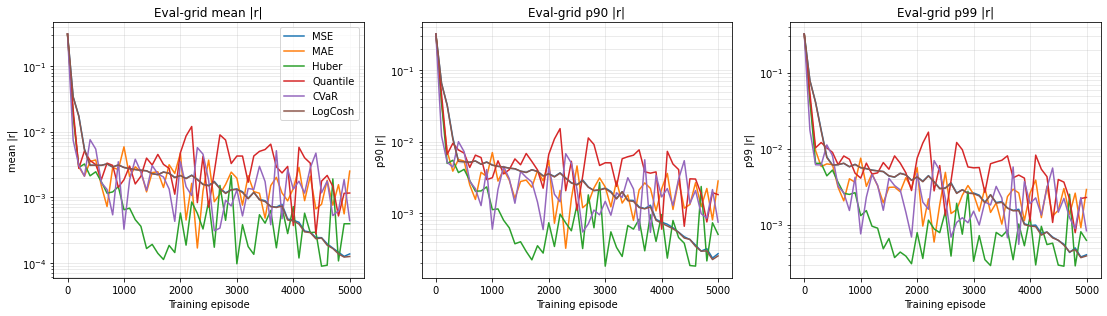

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
for kind in LOSS_KINDS:
    r = results[kind]
    axes[0].semilogy(r['eval_eps'], r['eval_mean'], label=kind)
    axes[1].semilogy(r['eval_eps'], r['eval_p90'],  label=kind)
    axes[2].semilogy(r['eval_eps'], r['eval_p99'],  label=kind)
for ax, t in zip(axes, ['mean |r|', 'p90 |r|', 'p99 |r|']):
    ax.set_xlabel('Training episode'); ax.set_ylabel(t)
    ax.set_title(f'Eval-grid {t}'); ax.grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=10, loc='best')
plt.tight_layout(); plt.show()

## 9. Final economic metric: along an actual simulated path

After training, we forward-simulate each learned policy (and the closed-form
optimum $s^\star$) under the *same* fixed innovation sequence
(`PATH_INNOVATIONS`). At every state visited along the path we compute the
absolute relative Euler residual; we also compute the **consumption-
equivalent welfare loss** of the learned policy versus $s^\star$,

$$\lambda \;=\; 1 - \exp\!\Big((1-\beta)\,(U_{\text{learned}} - U^\star)\Big),$$

the fraction of consumption that the agent would forgo to switch from the
learned policy to the optimum.

In [11]:
@tf.function(reduce_retracing=True)
def simulate_with_policy(policy_fn, T, z0, lk0, innovations):
    log_c = tf.TensorArray(tf.float32, size=T)
    states_hist = tf.TensorArray(tf.float32, size=T, element_shape=[2])
    z, lk = z0, lk0
    for t in tf.range(T):
        state_t = tf.stack([[z, lk]], axis=0)
        states_hist = states_hist.write(t, state_t[0])
        s_t = policy_fn(state_t)[0, 0]
        Z_t = tf.exp(z); K_t = tf.exp(lk)
        Y_t = Z_t * K_t**alpha
        c_t = (1.0 - s_t) * Y_t
        log_c = log_c.write(t, tf.math.log(c_t))
        K_tp1 = s_t * Y_t
        lk = tf.math.log(K_tp1)
        z = rho_tfp * z + sigma_tfp * innovations[t]
    return log_c.stack(), states_hist.stack()

def utility(log_c, beta_=beta):
    T = tf.shape(log_c)[0]
    discount = beta_ ** tf.cast(tf.range(T), tf.float32)
    return tf.reduce_sum(discount * log_c)

# Optimal policy: constant savings rate s*
s_star_tf = tf.constant(s_star, dtype=tf.float32)
def s_opt(state): return tf.fill((tf.shape(state)[0], 1), s_star_tf)

z0_tf  = tf.constant(0.0, dtype=tf.float32)
lk0_tf = tf.constant(lk_ss, dtype=tf.float32)
log_c_opt, _ = simulate_with_policy(s_opt, T_PATH, z0_tf, lk0_tf, PATH_INNOVATIONS)
U_opt = utility(log_c_opt)

summary_rows = []
for kind in LOSS_KINDS:
    nn = results[kind]['nn']
    log_c, states_hist = simulate_with_policy(lambda s: nn(s), T_PATH,
                                              z0_tf, lk0_tf, PATH_INNOVATIONS)
    U = utility(log_c)
    lam = 1.0 - float(tf.exp((1.0 - beta) * (U - U_opt)).numpy())  # CE welfare loss
    # Euler residual at every state actually visited
    ar_path = np.abs(euler_residual(states_hist, nn).numpy().ravel())
    summary_rows.append((kind, ar_path.mean(), np.median(ar_path),
                         np.quantile(ar_path, 0.9), np.quantile(ar_path, 0.99),
                         ar_path.max(), lam))
    results[kind]['path_residuals'] = ar_path
    results[kind]['CE_loss'] = lam

print(f'Path length T = {T_PATH}; closed-form s* = {s_star:.4f}')
print()
print(f'{"Loss":<10}{"mean |r|":>12}{"p50":>12}{"p90":>12}{"p99":>12}{"max":>12}{"CE loss":>12}')
print('-' * 82)
for k, m, p50, p90, p99, mx, lam in summary_rows:
    print(f'{k:<10}{m:>12.2e}{p50:>12.2e}{p90:>12.2e}{p99:>12.2e}{mx:>12.2e}{lam*100:>11.4f}%')

Path length T = 2000; closed-form s* = 0.3564

Loss          mean |r|         p50         p90         p99         max     CE loss
----------------------------------------------------------------------------------
MSE           1.59e-04    1.63e-04    2.63e-04    2.98e-04    3.57e-04     0.0000%
MAE           2.48e-03    2.47e-03    2.73e-03    2.87e-03    2.96e-03     0.0003%
Huber         3.80e-04    3.74e-04    4.83e-04    5.32e-04    6.46e-04     0.0000%
Quantile      1.01e-03    9.87e-04    1.17e-03    1.64e-03    2.30e-03     0.0000%
CVaR          4.35e-04    4.38e-04    6.94e-04    7.95e-04    8.79e-04     0.0000%
LogCosh       1.37e-04    1.39e-04    2.43e-04    2.80e-04    3.42e-04    -0.0000%


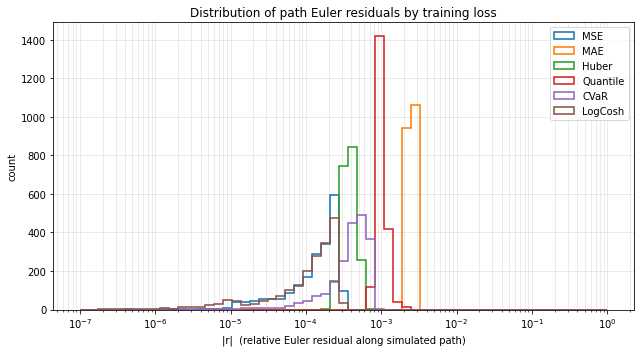

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
bins = np.logspace(-7, 0, 60)
for kind in LOSS_KINDS:
    ax.hist(results[kind]['path_residuals'], bins=bins, histtype='step',
            linewidth=1.6, label=kind)
ax.set_xscale('log'); ax.set_xlabel('|r|  (relative Euler residual along simulated path)')
ax.set_ylabel('count'); ax.set_title('Distribution of path Euler residuals by training loss')
ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Do all six policies reach the same stochastic steady state?

A natural fairness question: each kernel produces a slightly different policy, so each one will simulate a slightly different ergodic distribution of capital under the same shocks. The closed-form optimum sits at $s^\star = \alpha\beta$ exactly; if a kernel converges to a near-optimal policy, the resulting stochastic steady state should be near-identical to the optimum's. The block below verifies this directly: each policy is forward-simulated under `PATH_INNOVATIONS` for `T_PATH = 2000` periods, the first 200 periods are dropped as burn-in, and the remaining ergodic window is used to compute the mean and standard deviation of $\log K_t$, of the realised savings rate $s_t$, and of output $e^{z_t} K_t^\alpha$.  All six rows should be close to the OPTIMAL row; differences quantify how much each kernel's residual error perturbs the simulated economy.

In [13]:
import numpy as np

T_BURN = 200
print(f'Stochastic steady-state moments  (T={T_PATH}, dropping first {T_BURN} periods):')
print()
print(f'{"Policy":<10}{"E[log K]":>12}{"Std[log K]":>12}{"E[s_t]":>12}{"Std[s_t]":>12}{"E[Y_t]":>12}')
print('-' * 70)

# OPTIMAL: s* constant
_, st = simulate_with_policy(s_opt, T_PATH, z0_tf, lk0_tf, PATH_INNOVATIONS)
st_np = st.numpy()
z   = st_np[T_BURN:, 0]
lk  = st_np[T_BURN:, 1]
s_t = np.full_like(lk, s_star)
Y_t = np.exp(z) * np.exp(lk) ** alpha
print(f'{"OPTIMAL":<10}{lk.mean():>12.4f}{lk.std():>12.4f}{s_t.mean():>12.4f}{s_t.std():>12.4f}{Y_t.mean():>12.4f}')

ss_rows = []
for kind in LOSS_KINDS:
    nn = results[kind]['nn']
    _, st = simulate_with_policy(lambda s: nn(s), T_PATH, z0_tf, lk0_tf, PATH_INNOVATIONS)
    st_np = st.numpy()
    z   = st_np[T_BURN:, 0]
    lk  = st_np[T_BURN:, 1]
    s_t = nn(tf.constant(st_np[T_BURN:])).numpy().ravel()
    Y_t = np.exp(z) * np.exp(lk) ** alpha
    ss_rows.append((kind, lk.mean(), lk.std(), s_t.mean(), s_t.std(), Y_t.mean()))
    print(f'{kind:<10}{lk.mean():>12.4f}{lk.std():>12.4f}{s_t.mean():>12.4f}{s_t.std():>12.4f}{Y_t.mean():>12.4f}')

print()
print('Reading: column E[s_t] should be close to alpha * beta = ' f'{s_star:.4f}.')
print('         Std[s_t] is the spread of the learned savings rate around the optimum;')
print('         it is exactly zero for the closed-form optimum and grows with residual error.')


Stochastic steady-state moments  (T=2000, dropping first 200 periods):

Policy        E[log K]  Std[log K]      E[s_t]    Std[s_t]      E[Y_t]
----------------------------------------------------------------------
OPTIMAL        -1.6210      0.1288      0.3564      0.0000      0.5594


MSE            -1.6212      0.1287      0.3563      0.0000      0.5594


MAE            -1.6171      0.1285      0.3573      0.0001      0.5602


Huber          -1.6216      0.1287      0.3563      0.0000      0.5593


Quantile       -1.6194      0.1289      0.3568      0.0001      0.5597


CVaR           -1.6216      0.1285      0.3562      0.0001      0.5593


LogCosh        -1.6212      0.1287      0.3564      0.0000      0.5594

Reading: column E[s_t] should be close to alpha * beta = 0.3564.
         Std[s_t] is the spread of the learned savings rate around the optimum;
         it is exactly zero for the closed-form optimum and grows with residual error.


## 11. Where in the state space does each loss leave error?

Heat-map of $|s_{\text{learned}}(z, \log K) - s^\star|$ on the evaluation grid.
Bright spots flag regions where the learned policy disagrees with the
closed-form optimum.

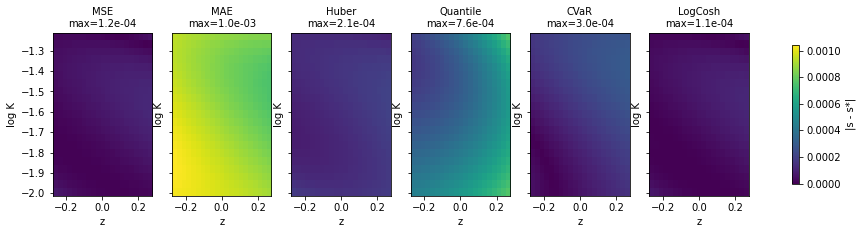

In [14]:
n = len(LOSS_KINDS)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.0), sharex=True, sharey=True)
err_maps, vmax = {}, 0.0
for kind in LOSS_KINDS:
    nn = results[kind]['nn']
    s_pred = nn(EVAL_STATES).numpy().ravel().reshape(ZZ.shape)
    err_maps[kind] = np.abs(s_pred - s_star)
    vmax = max(vmax, err_maps[kind].max())
for ax, kind in zip(axes, LOSS_KINDS):
    im = ax.imshow(err_maps[kind].T, origin='lower',
                   extent=[z_eval_grid[0], z_eval_grid[-1], lk_eval_grid[0], lk_eval_grid[-1]],
                   aspect='auto', vmin=0, vmax=vmax, cmap='viridis')
    ax.set_title(f'{kind}\nmax={err_maps[kind].max():.1e}', fontsize=10)
    ax.set_xlabel('z'); ax.set_ylabel('log K')
fig.colorbar(im, ax=axes.tolist(), shrink=0.85, label='|s - s*|')
plt.show()

## 12. Discussion

Several patterns typically emerge from the run above.

**MSE drives the bulk down fast** but its quadratic gradient also amplifies any outlier residual; in practice this means MSE training curves look smooth on average but can have visible jitter when an unusual mini-batch lands.

**MAE stalls at a finite floor.** The gradient of $|r|$ has *constant* magnitude (its sign), so once residuals are small, the optimizer takes the same step regardless of how close to zero it already is. The result is a clean log-curve that levels off and refuses to drop further. This is exactly the textbook MAE pathology, made visible here on a smooth model.

**Huber is robust but kinked.** It mimics MSE for $|r| \le \delta$ and MAE for $|r| > \delta$, so it inherits MSE's fine-convergence behaviour in the bulk and MAE's outlier robustness. The downside: the gradient has a *jump* at $|r|=\delta$, which can introduce small training-loop oscillations as residuals migrate across that threshold.

**Quantile and CVaR explicitly target the tail.** They typically deliver the narrowest spread between mean and max residual, at a small cost in mean (Quantile pays the most because it ignores most of the distribution by construction). When the *worst-case* policy quality matters, this is the right trade.

**LogCosh tends to converge most smoothly of the six.** It is the unique kernel here that is both $C^\infty$ everywhere *and* combines the two desirable asymptotic regimes: $\log\cosh(r) \approx \tfrac{1}{2} r^2$ for small $|r|$ (so it inherits MSE's fine-grained convergence near zero) and $\log\cosh(r) \approx |r| - \log 2$ for large $|r|$ (so its gradient saturates at $\pm 1$, which tames outliers like MAE). Crucially, **the transition between the two regimes is smooth**, with no kink as in Huber. Visually, the log-cosh convergence curve is essentially monotone with no spikes; numerically, it tracks MSE in the bulk and matches Huber on the tail. For most practical DEQN settings, log-cosh is therefore the lowest-risk choice when the modeller is unsure how rough or peaked the residual distribution will be in advance, and that is why it deserves a closer look beyond the usual MSE / Huber pair.

**The CE-welfare-loss ranking is not the same as the training-loss ranking.** Lifetime utility under log preferences is sensitive to outlier consumption realisations; a tail-aware loss can deliver lower welfare loss even when its mean Euler residual is larger.

**Take-away.** *We do not actually care about MSE.* We care about the behaviour of the policy along simulated equilibrium paths, in consumption-equivalent welfare terms. The training loss is just an instrument; choosing it with that hierarchy in mind is part of the modelling decision. For models with sharp non-linearities or rare-event regions (occasionally binding constraints, tipping risks, fat-tailed shocks), tail-aware kernels pay off. For smooth, well-behaved problems the difference is mostly cosmetic and MSE is fine - but log-cosh is rarely a bad default.

**Practical guidance.**

- Default to **MSE** unless you have a reason not to. **LogCosh** is a near-equivalent drop-in that is more forgiving when residuals are heavy-tailed; it is the lowest-risk choice when in doubt.
- Use **Huber** when training is unstable on a few outlier states (a common symptom: occasional loss spikes that re-converge slowly). Note that the kink at $|r|{=}\delta$ can itself induce mild oscillation.
- Use **Quantile** $\tau{=}0.9$ or **CVaR** $\alpha{=}0.9$ when the *worst-case* policy quality matters: occasionally binding constraints, rare-but-consequential states, regulatory back-tests.
- **Avoid MAE** as the sole training loss for fine-grained convergence: its constant gradient magnitude prevents the optimizer from making smaller steps as residuals shrink, and it stalls at a noise-floor that is much higher than what MSE / log-cosh / Huber attain at the same training budget.
- Always evaluate on the *economic* metric, the relative Euler residual along simulated paths, not on the training loss itself.

**Further exercises.**

- Sweep the quantile level $\tau \in \{0.5, 0.9, 0.99\}$ and watch the bias-variance trade-off shift.
- Combine losses: $\ell = \ell_{\text{MSE}} + \eta\, \ell_{\text{CVaR}}$ with $\eta$ small. This typically gives the cleanest convergence both in the bulk and the tail.
- Re-run with $\delta=0.1$ (the partial-depreciation Day-2 calibration). The closed-form benchmark is no longer available, but the relative ranking of losses on path Euler residuals should be qualitatively the same.
- Repeat the experiment with the Day-3 IRBC notebook; tail-aware losses matter more when the state dimension grows.